# Cold-Start Airbnb Listing Predictor  

### Author: Andrea Suardi  
*Date: October 2025*  
[GitHub Repository](https://github.com/Andrea-Suardi)  

---

## Project Overview  
This notebook explores how machine learning can address the **cold-start problem** in Airbnb listings — predicting whether newly added NYC properties are likely to be “High-Potential” (top 25% ratings, ≥4.9) before any reviews are available.  

By modeling listing characteristics such as **price, amenities, and location**, the goal is to help identify and promote trustworthy new properties, supporting early recommendations and improving user experience.

---

## Objectives  
- Build a binary classifier to distinguish *High-Potential* vs *Standard* listings.  
- Identify key predictive features influencing listing quality.  
- Evaluate model precision and interpretability through internal and prospective validation (on 2025 data).  
- Demonstrate an end-to-end workflow: preprocessing → feature engineering → modeling → evaluation.  

---

## Tools & Libraries  
- **Python:** Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn  
- **Environment:** Jupyter Notebook  
- **Additional:** Generative AI tools for ideation and documentation support  

---

## Notebook Structure  
1. **Data Understanding** 

---

## Notes  
This project is ongoing and currently focuses on data exploration and feature design.  
Subsequent updates will include model benchmarking and prospective validation.


In [1]:
# import required libraries
import pandas as pd

# Data Understanding
In this section i will perform some checks to decide which data use for model development and for prospective evaluation

In [8]:
#import data
listings_2022 = pd.read_csv("NYC_2022.csv",low_memory=False)
listings_2023 = pd.read_csv("NYC_2022.csv",low_memory=False)
listings_2024 = pd.read_excel("NYC_2023.xlsx")
listings_2025 = pd.read_csv("NYC_2022.csv",low_memory=False)

In [30]:
#check if the columns have same names
print("2022-2023:", set(listings_2022.columns) == set(listings_2023.columns))
print("2022-2024:", set(listings_2022.columns) == set(listings_2024.columns))
print("2022-2025:", set(listings_2022.columns) == set(listings_2025.columns))
print("2023-2024:", set(listings_2023.columns) == set(listings_2024.columns))
print("2023-2025:", set(listings_2023.columns) == set(listings_2025.columns))
print("2024-2025:", set(listings_2024.columns) == set(listings_2025.columns))

2022-2023: True
2022-2024: False
2022-2025: True
2023-2024: False
2023-2025: True
2024-2025: False


In [9]:
print(f"Total listings: {len(listings)}")
print(f"less than 5-review listings: {len(listings_2022[listings_2022['number_of_reviews'] < 5])}")
print(f"0-review listings: {len(listings_2022[listings_2022['number_of_reviews'] ==0])}")
reviewed = listings_2022[listings_2022['number_of_reviews'] >= 5]
print(f"Reviewed (>=5): {len(reviewed)}")
avg_reviews = listings_2022[listings_2022['number_of_reviews'] >= 5]['review_scores_rating'].mean()
print(f"Avg review score per listing with at least 5 reviews: {avg_reviews:.1f}")

Total listings: 37410
less than 5-review listings: 17785
0-review listings: 7949
Reviewed (>=5): 19625
Avg review score per listing with at least 5 reviews: 4.7


In [19]:
listings_2025 = pd.read_csv("NYC_2025.csv")

In [7]:
zero_2022 = listings_2022[listings_2022['number_of_reviews'] < 5]['id']
persistents = zero_2022[zero_2022.isin(listings_2025['id'])]
attrition = 1 - (len(persistents) / len(zero_2022))
print(f"Attrition Rate: {attrition:.2%}, Persistents: {len(persistents)}")
# With reviews in 2024
with_reviews = persistents[persistents.isin(listings_2025[listings_2025['number_of_reviews']>4]['id'])]
print(f"Persistents that at 2025 have >4 reviews: {len(with_reviews)}")
# Avg reviews for those
avg_rev_persist = listings_2025[listings_2025['id'].isin(with_reviews)]['review_scores_rating'].mean()
print(f"Avg reviews score for persistents in 2025: {avg_rev_persist:.1f}")

Attrition Rate: 47.59%, Persistents: 9321
Persistents that at 2025 have >4 reviews: 1423
Avg reviews score for persistents in 2025: 4.8


In [13]:
listings_2022['price']=listings_2022['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [22]:
listings_2025['price']=listings_2025['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [26]:
print(f"2022 Avg Price: ${listings_2022['price'].mean():.0f}")
print(f"2025 Avg Price: ${listings_2025['price'].mean():.0f}")
print(f"2022 Short-term % (min_nights <30): {(listings_2022['minimum_nights'] < 30).mean():.1%}")
print(f"2025 Short-term %: {(listings_2025['minimum_nights'] < 30).mean():.1%}")

2022 Avg Price: $191
2025 Avg Price: $681
2022 Short-term % (min_nights <30): 49.6%
2025 Short-term %: 14.4%


In [41]:
listings_2022[listings_2022['number_of_reviews'] > 4]['review_scores_rating'].describe()

count    19625.000000
mean         4.734277
std          0.265926
min          0.000000
25%          4.630000
50%          4.800000
75%          4.920000
max          5.000000
Name: review_scores_rating, dtype: float64

<Axes: >

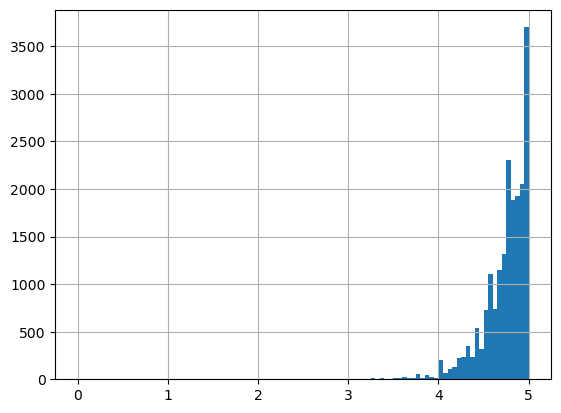

In [40]:
listings_2022[listings_2022['number_of_reviews'] > 4]['review_scores_rating'].hist(bins=100)